# Last Mile Logistics Auditor

**Client:** Veridi Logistics
**Question:** Are late deliveries a few bad regions, or a nationwide promise problem?

This notebook builds one master row per order, measures how far the estimated delivery date missed the actual delivery date, and connects that miss to customer review scores and Brazilian states.

Raw CSVs live in `data/` next to this notebook. Paths are relative, so the notebook runs from this folder without a machine-specific path.

## 1. Schema builder

Orders, reviews, and customers are joined so each row has a location and a review score.

Reviews are not 1:1 with orders (some orders have more than one review). Those reviews are collapsed to a single row per `order_id` before the join, so the master table stays the same length as the orders table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="white", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

print(f"orders:    {len(orders):,} rows | {orders['order_id'].nunique():,} order_id")
print(f"reviews:   {len(reviews):,} rows | {reviews['order_id'].nunique():,} order_id")
print(f"customers: {len(customers):,} rows | {customers['customer_id'].nunique():,} customer_id")

orders:    99,441 rows | 99,441 order_id
reviews:   99,224 rows | 98,673 order_id
customers: 99,441 rows | 99,441 customer_id


In [2]:
review_counts = reviews.groupby("order_id").size()
multi_review_orders = int((review_counts > 1).sum())

reviews_one = (
    reviews.sort_values(["order_id", "review_creation_date"])
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "size"),
        review_creation_date=("review_creation_date", "max"),
    )
)

master = orders.merge(customers, on="customer_id", how="left", validate="one_to_one")
master = master.merge(reviews_one, on="order_id", how="left", validate="one_to_one")

assert len(master) == len(orders), "Join duplicated order rows"
assert master["order_id"].is_unique
assert master["customer_state"].isna().sum() == 0

print(f"Orders with more than one review (collapsed): {multi_review_orders:,}")
print(f"Master rows: {len(master):,} (matches orders)")
print(f"Orders with a review: {master['review_score'].notna().sum():,}")
master[["order_id", "customer_state", "customer_city", "order_status", "review_score", "review_count"]].head()

Orders with more than one review (collapsed): 547
Master rows: 99,441 (matches orders)
Orders with a review: 98,673


,order_id,customer_state,customer_city,order_status,review_score,review_count
0,e481f51cbdc54678b7cc49136f2d6af7,SP,sao paulo,delivered,4.00,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,BA,barreiras,delivered,4.00,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,GO,vianopolis,delivered,5.00,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,RN,sao goncalo do amarante,delivered,5.00,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,SP,santo andre,delivered,5.00,1.00


## 2. The real delay calculator

`Days_Difference` = estimated delivery date − actual delivery date, compared on the calendar date (the promise customers see).

- **Positive:** arrived before the promised date
- **Zero:** arrived on the promised date
- **Negative:** arrived after the promised date

Status rules for delivered orders:

- **On Time:** `Days_Difference >= 0`
- **Late:** 1 to 5 days after the promise
- **Super Late:** more than 5 days after the promise

Orders that were never delivered (`canceled`, `unavailable`, or any status still missing an actual delivery date) are flagged as **Not Delivered** and kept out of the late-rate denominator.

In [3]:
NOT_DELIVERED_STATUS = {"canceled", "unavailable"}

delivered_mask = (
    (master["order_status"] == "delivered")
    & master["order_delivered_customer_date"].notna()
    & master["order_estimated_delivery_date"].notna()
)

master["Days_Difference"] = (
    master["order_estimated_delivery_date"].dt.normalize()
    - master["order_delivered_customer_date"].dt.normalize()
).dt.days

master["delivery_status"] = np.where(
    ~delivered_mask,
    "Not Delivered",
    np.where(
        master["Days_Difference"] >= 0,
        "On Time",
        np.where(master["Days_Difference"] >= -5, "Late", "Super Late"),
    ),
)
master["is_late"] = master["delivery_status"].isin(["Late", "Super Late"])

# Lead times answer whether the promise itself was too aggressive.
master["actual_lead_days"] = (
    master["order_delivered_customer_date"].dt.normalize()
    - master["order_purchase_timestamp"].dt.normalize()
).dt.days
master["promised_lead_days"] = (
    master["order_estimated_delivery_date"].dt.normalize()
    - master["order_purchase_timestamp"].dt.normalize()
).dt.days

performance = master.loc[delivered_mask].copy()

status_order = ["On Time", "Late", "Super Late", "Not Delivered"]
status_summary = (
    master["delivery_status"]
    .value_counts()
    .reindex(status_order)
    .rename_axis("delivery_status")
    .reset_index(name="orders")
)
status_summary["share_of_all_orders"] = status_summary["orders"] / len(master)

late_share = performance["is_late"].mean()
super_late_share = (performance["delivery_status"] == "Super Late").mean()
print(f"Delivered orders in the audit: {len(performance):,}")
print(f"Late (including super late): {late_share:.1%}")
print(f"Super late (>5 days): {super_late_share:.1%}")
print(f"Median Days_Difference (positive = early): {performance['Days_Difference'].median():.0f} days")
status_summary

Delivered orders in the audit: 96,470
Late (including super late): 6.8%
Super late (>5 days): 3.9%
Median Days_Difference (positive = early): 12 days


,delivery_status,orders,share_of_all_orders
0,On Time,89936,0.90
1,Late,2770,0.03
2,Super Late,3764,0.04
3,Not Delivered,2971,0.03


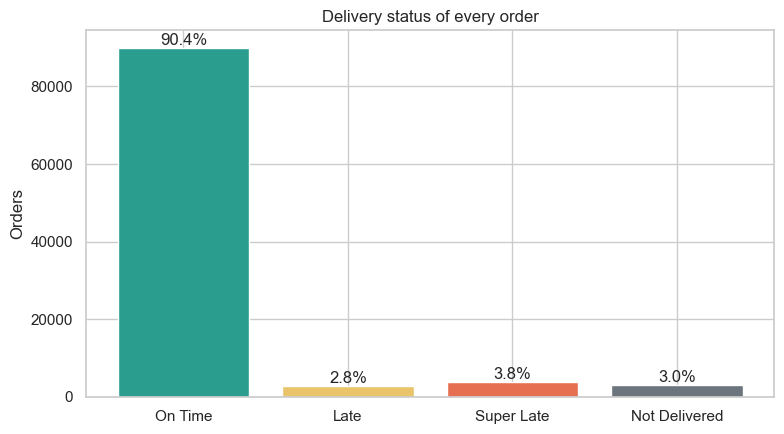

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {
    "On Time": "#2a9d8f",
    "Late": "#e9c46a",
    "Super Late": "#e76f51",
    "Not Delivered": "#6c757d",
}
plot_df = status_summary.set_index("delivery_status")
ax.bar(plot_df.index, plot_df["orders"], color=[colors[s] for s in plot_df.index])
ax.set_title("Delivery status of every order")
ax.set_ylabel("Orders")
ax.set_xlabel("")
for i, (status, row) in enumerate(plot_df.iterrows()):
    ax.text(i, row["orders"], f"{row['share_of_all_orders']:.1%}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "delivery_status.png", dpi=140)
plt.show()

## 3. Geographic heatmap (state late rates)

Late rate = share of **delivered** orders that missed the promised date (`Late` + `Super Late`). Undelivered orders are excluded so a canceled order is not counted as a late truck.

Brazilian e-commerce volume is concentrated in the Southeast (SP, RJ, MG, ES), close to the main seller base. North and parts of the Northeast are the remote comparison group.

In [5]:
REGION = {
    "SP": "Southeast", "RJ": "Southeast", "MG": "Southeast", "ES": "Southeast",
    "PR": "South", "SC": "South", "RS": "South",
    "DF": "Central-West", "GO": "Central-West", "MT": "Central-West", "MS": "Central-West",
    "BA": "Northeast", "CE": "Northeast", "PE": "Northeast", "MA": "Northeast",
    "PB": "Northeast", "RN": "Northeast", "AL": "Northeast", "PI": "Northeast", "SE": "Northeast",
    "PA": "North", "AM": "North", "RO": "North", "AC": "North",
    "RR": "North", "AP": "North", "TO": "North",
}
performance["region"] = performance["customer_state"].map(REGION)

state_stats = (
    performance.groupby(["customer_state", "region"], as_index=False)
    .agg(
        delivered_orders=("order_id", "size"),
        late_orders=("is_late", "sum"),
        super_late_orders=("delivery_status", lambda s: (s == "Super Late").sum()),
        avg_days_difference=("Days_Difference", "mean"),
        median_days_difference=("Days_Difference", "median"),
        avg_review_score=("review_score", "mean"),
        avg_actual_lead_days=("actual_lead_days", "mean"),
        avg_promised_lead_days=("promised_lead_days", "mean"),
    )
)
state_stats["late_rate"] = state_stats["late_orders"] / state_stats["delivered_orders"]
state_stats["super_late_rate"] = state_stats["super_late_orders"] / state_stats["delivered_orders"]
state_stats = state_stats.sort_values("late_rate", ascending=False)

national_late_rate = performance["is_late"].mean()
print(f"National late rate: {national_late_rate:.1%}")
print("Highest late rates:")
display_cols = ["customer_state", "region", "delivered_orders", "late_rate", "super_late_rate", "avg_days_difference", "avg_review_score"]
state_stats[display_cols].head(8)

National late rate: 6.8%
Highest late rates:


,customer_state,region,delivered_orders,late_rate,super_late_rate,avg_days_difference,avg_review_score
1,AL,Northeast,397,0.21,0.13,8.71,3.85
9,MA,Northeast,717,0.17,0.10,9.57,3.83
24,SE,Northeast,335,0.15,0.12,10.02,3.91
16,PI,Northeast,476,0.14,0.07,11.31,3.99
5,CE,Northeast,1279,0.14,0.10,10.80,3.94
21,RR,North,41,0.12,0.10,17.29,3.90
4,BA,Northeast,3256,0.12,0.08,10.79,3.93
18,RJ,Southeast,12350,0.12,0.09,11.76,3.97


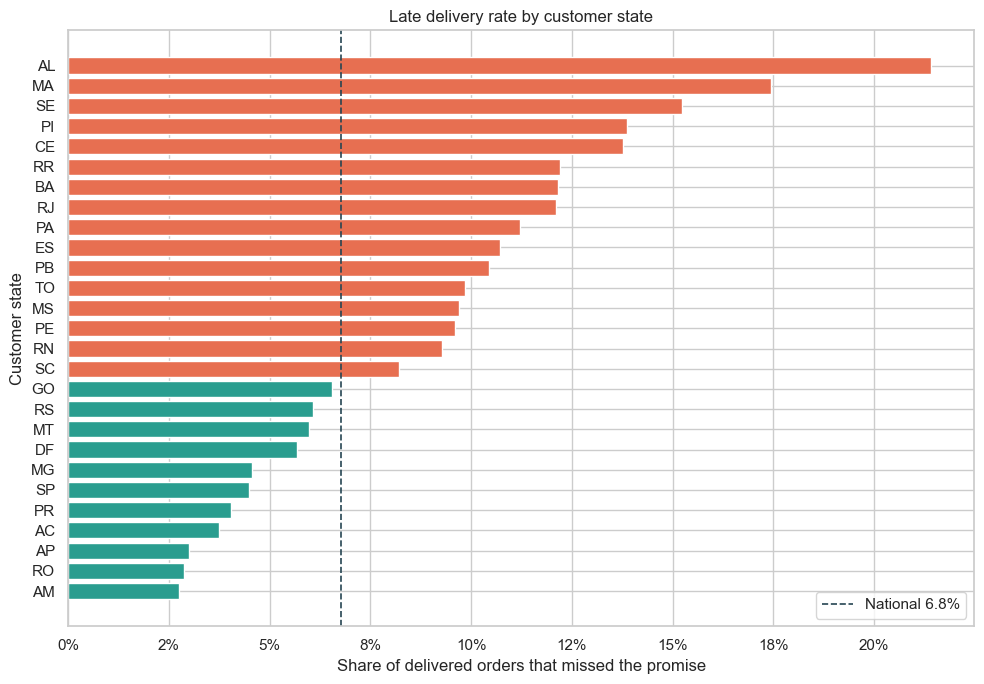

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
chart = state_stats.sort_values("late_rate", ascending=True)
bar_colors = ["#e76f51" if r > national_late_rate else "#2a9d8f" for r in chart["late_rate"]]
ax.barh(chart["customer_state"], chart["late_rate"], color=bar_colors)
ax.axvline(national_late_rate, color="#264653", linestyle="--", linewidth=1.2, label=f"National {national_late_rate:.1%}")
ax.set_xlabel("Share of delivered orders that missed the promise")
ax.set_ylabel("Customer state")
ax.set_title("Late delivery rate by customer state")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "late_rate_by_state.png", dpi=140)
plt.show()

In [7]:
region_stats = (
    performance.groupby("region", as_index=False)
    .agg(
        delivered_orders=("order_id", "size"),
        late_rate=("is_late", "mean"),
        super_late_rate=("delivery_status", lambda s: (s == "Super Late").mean()),
        avg_days_difference=("Days_Difference", "mean"),
        avg_actual_lead_days=("actual_lead_days", "mean"),
        avg_promised_lead_days=("promised_lead_days", "mean"),
        avg_review_score=("review_score", "mean"),
    )
    .sort_values("late_rate", ascending=False)
)
region_stats

,region,delivered_orders,late_rate,super_late_rate,avg_days_difference,avg_actual_lead_days,avg_promised_lead_days,avg_review_score
2,Northeast,9044,0.13,0.08,11.34,19.95,31.29,3.97
1,North,1796,0.09,0.06,15.61,22.54,38.15,4.03
0,Central-West,5624,0.07,0.03,12.34,14.95,27.29,4.13
4,Southeast,66193,0.06,0.03,11.56,10.69,22.25,4.18
3,South,13813,0.06,0.03,13.08,13.98,27.06,4.19


## 4. Sentiment correlation

If logistics is the review problem, review scores should fall as `Days_Difference` turns negative, and On Time orders should score higher than Late and Super Late orders.

In [8]:
reviewed = performance.dropna(subset=["review_score"]).copy()

def delay_bin(days: float) -> str:
    if days >= 8:
        return "8+ days early"
    if days >= 1:
        return "1–7 days early"
    if days == 0:
        return "On the promised day"
    if days >= -5:
        return "1–5 days late"
    if days >= -10:
        return "6–10 days late"
    return "11+ days late"

bin_order = [
    "8+ days early",
    "1–7 days early",
    "On the promised day",
    "1–5 days late",
    "6–10 days late",
    "11+ days late",
]
reviewed["delay_bin"] = reviewed["Days_Difference"].map(delay_bin)
score_by_bin = (
    reviewed.groupby("delay_bin", as_index=False)
    .agg(orders=("order_id", "size"), avg_review_score=("review_score", "mean"))
)
score_by_bin["delay_bin"] = pd.Categorical(score_by_bin["delay_bin"], bin_order, ordered=True)
score_by_bin = score_by_bin.sort_values("delay_bin")

score_by_status = (
    reviewed.groupby("delivery_status", as_index=False)
    .agg(orders=("order_id", "size"), avg_review_score=("review_score", "mean"))
)
score_by_status["delivery_status"] = pd.Categorical(
    score_by_status["delivery_status"], ["On Time", "Late", "Super Late"], ordered=True
)
score_by_status = score_by_status.sort_values("delivery_status")
score_by_status

,delivery_status,orders,avg_review_score
1,On Time,89443,4.29
0,Late,2722,2.99
2,Super Late,3659,1.74


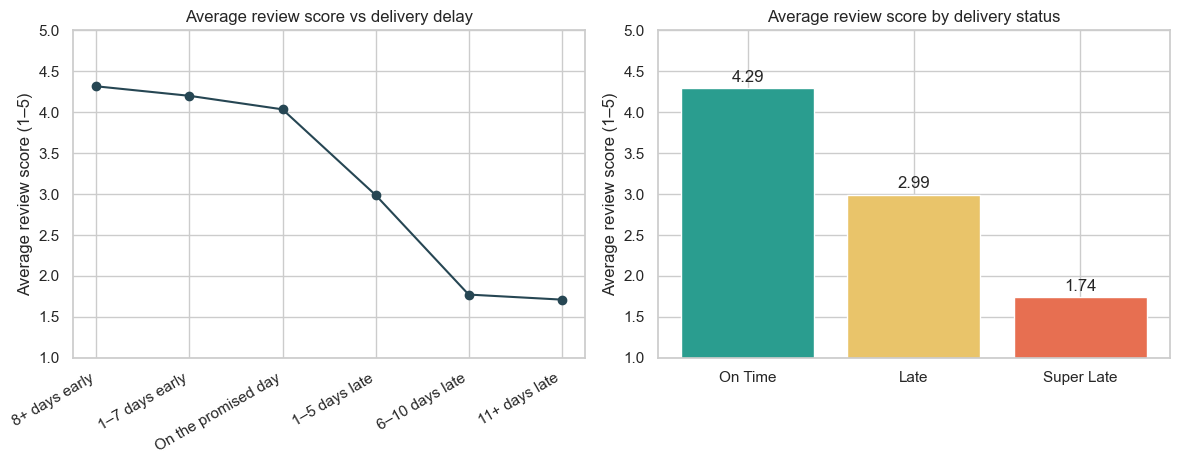

,delay_bin,orders,avg_review_score
4,8+ days early,70929,4.32
2,1–7 days early,17234,4.20
5,On the promised day,1280,4.04
1,1–5 days late,2722,2.99
3,6–10 days late,1634,1.77
0,11+ days late,2025,1.71


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(score_by_bin["delay_bin"].astype(str), score_by_bin["avg_review_score"], marker="o", color="#264653")
axes[0].set_ylim(1, 5)
axes[0].set_title("Average review score vs delivery delay")
axes[0].set_ylabel("Average review score (1–5)")
axes[0].tick_params(axis="x", rotation=30)
for label in axes[0].get_xticklabels():
    label.set_ha("right")

status_colors = ["#2a9d8f", "#e9c46a", "#e76f51"]
axes[1].bar(
    score_by_status["delivery_status"].astype(str),
    score_by_status["avg_review_score"],
    color=status_colors,
)
axes[1].set_ylim(1, 5)
axes[1].set_title("Average review score by delivery status")
axes[1].set_ylabel("Average review score (1–5)")
for i, row in score_by_status.reset_index(drop=True).iterrows():
    axes[1].text(i, row["avg_review_score"] + 0.08, f"{row['avg_review_score']:.2f}", ha="center")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "review_score_vs_delay.png", dpi=140)
plt.show()
score_by_bin

## 5. Bonus: product categories in English

`product_category_name` is Portuguese. The translation file maps it to English so category comparisons are readable.

This join is done on a **separate item-level table**. An order can contain several products, so those rows are not merged back into the master order table.

In [10]:
items_enriched = items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
items_enriched = items_enriched.merge(category_translation, on="product_category_name", how="left")
items_enriched["category_english"] = items_enriched["product_category_name_english"].fillna("unknown")

# One category label per order: the category of the highest-priced item.
primary_item = (
    items_enriched.sort_values(["order_id", "price"], ascending=[True, False])
    .drop_duplicates("order_id")
    [["order_id", "category_english", "price", "freight_value"]]
)
category_orders = performance.merge(primary_item, on="order_id", how="left")
category_orders["category_english"] = category_orders["category_english"].fillna("unknown")

category_stats = (
    category_orders.groupby("category_english", as_index=False)
    .agg(
        delivered_orders=("order_id", "size"),
        late_rate=("is_late", "mean"),
        super_late_rate=("delivery_status", lambda s: (s == "Super Late").mean()),
        avg_review_score=("review_score", "mean"),
        avg_days_difference=("Days_Difference", "mean"),
    )
)
# Keep categories with enough volume to trust the rate.
category_focus = category_stats.loc[category_stats["delivered_orders"] >= 200].sort_values("late_rate", ascending=False)
print("Categories with at least 200 delivered orders, worst late rate first:")
category_focus.head(10)

Categories with at least 200 delivered orders, worst late rate first:


,category_english,delivered_orders,late_rate,super_late_rate,avg_review_score,avg_days_difference
4,audio,344,0.12,0.08,3.85,10.01
47,home_confort,370,0.09,0.07,3.92,9.78
10,books_technical,254,0.08,0.03,4.42,11.25
6,baby,2761,0.08,0.05,4.12,11.46
57,office_furniture,1251,0.08,0.05,3.65,11.80
26,electronics,2502,0.08,0.04,4.13,10.97
40,furniture_living_room,409,0.08,0.04,4.07,11.58
56,musical_instruments,608,0.08,0.04,4.24,11.44
43,health_beauty,8613,0.08,0.04,4.23,11.97
7,bed_bath_table,9184,0.07,0.04,4.01,11.35


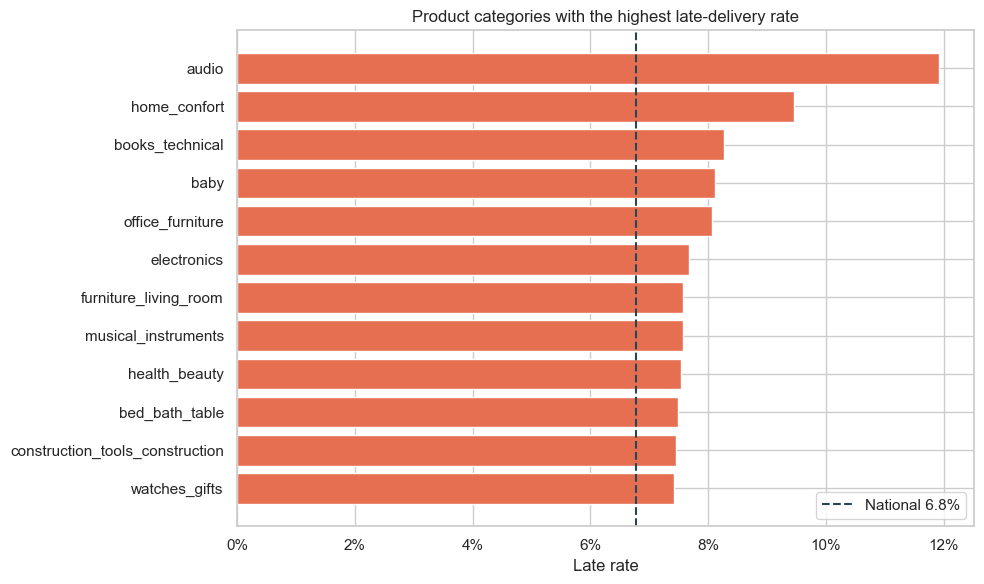

In [11]:
top_bottom = pd.concat(
    [
        category_focus.head(8).assign(group="Highest late rate"),
        category_focus.tail(8).assign(group="Lowest late rate"),
    ]
)
fig, ax = plt.subplots(figsize=(10, 6))
chart = category_focus.head(12).sort_values("late_rate", ascending=True)
ax.barh(chart["category_english"], chart["late_rate"], color="#e76f51")
ax.axvline(national_late_rate, color="#264653", linestyle="--", label=f"National {national_late_rate:.1%}")
ax.set_xlabel("Late rate")
ax.set_title("Product categories with the highest late-delivery rate")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "late_rate_by_category.png", dpi=140)
plt.show()

## 6. Candidate's choice: promise bias, not just carrier speed

Late rate says a state missed the date. It does not say whether the truck was slow or the date we showed the customer was too optimistic.

For each region this section compares:

- **Promised lead time:** purchase date → estimated delivery date
- **Actual lead time:** purchase date → delivered date
- **Days_Difference:** the buffer we had left (negative means the promise ran out)

If remote regions are given a similar promise window but need many more days on the road, the ETA model is the lever, not only the local carrier.

In [12]:
promise_bias = region_stats.copy()
promise_bias["buffer_days"] = promise_bias["avg_promised_lead_days"] - promise_bias["avg_actual_lead_days"]
promise_bias = promise_bias.sort_values("buffer_days")
promise_bias[
    [
        "region",
        "delivered_orders",
        "late_rate",
        "avg_promised_lead_days",
        "avg_actual_lead_days",
        "buffer_days",
        "avg_review_score",
    ]
]

,region,delivered_orders,late_rate,avg_promised_lead_days,avg_actual_lead_days,buffer_days,avg_review_score
2,Northeast,9044,0.13,31.29,19.95,11.34,3.97
4,Southeast,66193,0.06,22.25,10.69,11.56,4.18
0,Central-West,5624,0.07,27.29,14.95,12.34,4.13
3,South,13813,0.06,27.06,13.98,13.08,4.19
1,North,1796,0.09,38.15,22.54,15.61,4.03


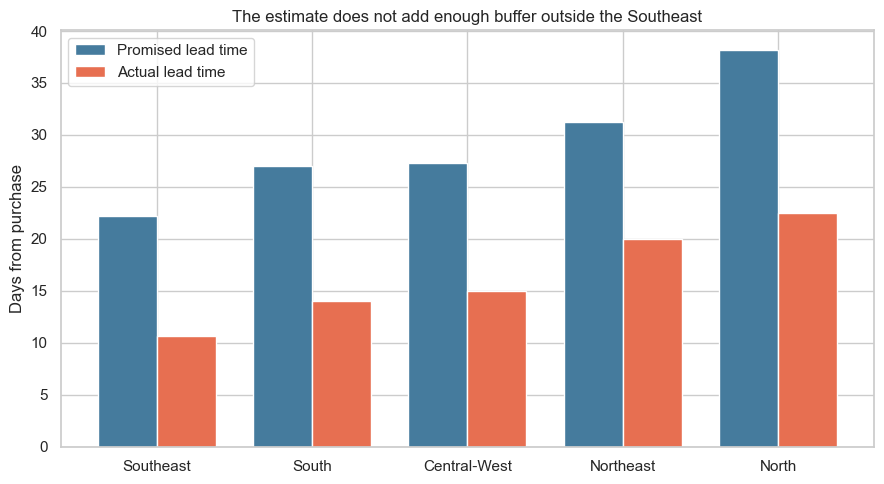

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(promise_bias))
width = 0.38
order = promise_bias.sort_values("avg_actual_lead_days")
ax.bar(x - width / 2, order["avg_promised_lead_days"], width, label="Promised lead time", color="#457b9d")
ax.bar(x + width / 2, order["avg_actual_lead_days"], width, label="Actual lead time", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels(order["region"])
ax.set_ylabel("Days from purchase")
ax.set_title("The estimate does not add enough buffer outside the Southeast")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "promise_vs_actual_by_region.png", dpi=140)
plt.show()

In [14]:
state_stats.to_csv(OUTPUT_DIR / "state_performance.csv", index=False)
region_stats.to_csv(OUTPUT_DIR / "region_performance.csv", index=False)
score_by_status.to_csv(OUTPUT_DIR / "review_by_status.csv", index=False)
score_by_bin.to_csv(OUTPUT_DIR / "review_by_delay_bin.csv", index=False)
category_focus.to_csv(OUTPUT_DIR / "category_performance.csv", index=False)
status_summary.to_csv(OUTPUT_DIR / "delivery_status_summary.csv", index=False)

on_time_score = float(score_by_status.loc[score_by_status["delivery_status"] == "On Time", "avg_review_score"].iloc[0])
late_score = float(score_by_status.loc[score_by_status["delivery_status"] == "Late", "avg_review_score"].iloc[0])
super_score = float(score_by_status.loc[score_by_status["delivery_status"] == "Super Late", "avg_review_score"].iloc[0])
worst_state = state_stats.iloc[0]
best_state = state_stats.sort_values("late_rate").iloc[0]
north = region_stats.loc[region_stats["region"] == "North"].iloc[0]
southeast = region_stats.loc[region_stats["region"] == "Southeast"].iloc[0]

print("AUDIT SNAPSHOT")
print(f"Delivered orders audited: {len(performance):,}")
print(f"National late rate: {national_late_rate:.1%}")
print(f"Super late rate: {super_late_share:.1%}")
print(f"Not delivered (flagged, excluded from late rate): {(master['delivery_status'] == 'Not Delivered').sum():,}")
print(f"Worst state: {worst_state['customer_state']} late rate {worst_state['late_rate']:.1%} (n={int(worst_state['delivered_orders']):,})")
print(f"Best state: {best_state['customer_state']} late rate {best_state['late_rate']:.1%} (n={int(best_state['delivered_orders']):,})")
print(f"North late rate {north['late_rate']:.1%} vs Southeast {southeast['late_rate']:.1%}")
print(f"Avg review — On Time {on_time_score:.2f} | Late {late_score:.2f} | Super Late {super_score:.2f}")
print(f"North promised {north['avg_promised_lead_days']:.1f}d vs actual {north['avg_actual_lead_days']:.1f}d")
print(f"Southeast promised {southeast['avg_promised_lead_days']:.1f}d vs actual {southeast['avg_actual_lead_days']:.1f}d")

AUDIT SNAPSHOT
Delivered orders audited: 96,470
National late rate: 6.8%
Super late rate: 3.9%
Not delivered (flagged, excluded from late rate): 2,971
Worst state: AL late rate 21.4% (n=397)
Best state: AM late rate 2.8% (n=145)
North late rate 8.6% vs Southeast 6.1%
Avg review — On Time 4.29 | Late 2.99 | Super Late 1.74
North promised 38.1d vs actual 22.5d
Southeast promised 22.2d vs actual 10.7d
